Conducting Exploratory Data Analysis on Amnes Housing Data for predciting House Prices.

In [295]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
df=pd.read_csv("train.csv")

In [297]:
df.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [298]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1459 entries, 0 to 1458
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1459 non-null   int64  
 1   MSSubClass     1459 non-null   int64  
 2   MSZoning       1455 non-null   str    
 3   LotFrontage    1232 non-null   float64
 4   LotArea        1459 non-null   int64  
 5   Street         1459 non-null   str    
 6   Alley          107 non-null    str    
 7   LotShape       1459 non-null   str    
 8   LandContour    1459 non-null   str    
 9   Utilities      1457 non-null   str    
 10  LotConfig      1459 non-null   str    
 11  LandSlope      1459 non-null   str    
 12  Neighborhood   1459 non-null   str    
 13  Condition1     1459 non-null   str    
 14  Condition2     1459 non-null   str    
 15  BldgType       1459 non-null   str    
 16  HouseStyle     1459 non-null   str    
 17  OverallQual    1459 non-null   int64  
 18  OverallCond    1459

In [299]:
df.head()


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,...,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal


Number of Unique/Distinct entries per feature.

In [300]:
df.nunique()

Id               1459
MSSubClass         16
MSZoning            5
LotFrontage       115
LotArea          1106
                 ... 
MiscVal            26
MoSold             12
YrSold              5
SaleType            9
SaleCondition       6
Length: 80, dtype: int64

Extracting categorical features

In [301]:
new_df=df.copy()
df_categoric=new_df.select_dtypes(include=['object', 'category'])

C:\Users\DELL\AppData\Local\Temp\ipykernel_20592\3418343237.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df_categoric=new_df.select_dtypes(include=['object', 'category'])


1. Numnber of unique entries in Categoric features.
2. Since Max number of distinct entries is 25 (<5% of total entries), we can conduct One-Hot Encoding for handling all Categoric features

In [302]:
max(df_categoric.nunique())

25

In [303]:
df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold
count,1459.000000,1459.000000,1232.000000,1459.000000,1459.000000,1459.000000,1459.000000,1459.000000,1444.000000,1458.000000,...,1458.000000,1459.000000,1459.000000,1459.000000,1459.000000,1459.000000,1459.000000,1459.000000,1459.000000,1459.000000
mean,2190.000000,57.378341,68.580357,9819.161069,6.078821,5.553804,1971.357779,1983.662783,100.709141,439.203704,...,472.768861,93.174777,48.313914,24.243317,1.794380,17.064428,1.744345,58.167923,6.104181,2007.769705
std,421.321334,42.746880,22.376841,4955.517327,1.436812,1.113740,30.390071,21.130467,177.625900,455.268042,...,217.048611,127.744882,68.883364,67.227765,20.207842,56.609763,30.491646,630.806978,2.722432,1.301740
min,1461.000000,20.000000,21.000000,1470.000000,1.000000,1.000000,1879.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000
25%,1825.500000,20.000000,58.000000,7391.000000,5.000000,5.000000,1953.000000,1963.000000,0.000000,0.000000,...,318.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,2007.000000
50%,2190.000000,50.000000,67.000000,9399.000000,6.000000,5.000000,1973.000000,1992.000000,0.000000,350.500000,...,480.000000,0.000000,28.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000
75%,2554.500000,70.000000,80.000000,11517.500000,7.000000,6.000000,2001.000000,2004.000000,164.000000,753.500000,...,576.000000,168.000000,72.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000
max,2919.000000,190.000000,200.000000,56600.000000,10.000000,9.000000,2010.000000,2010.000000,1290.000000,4010.000000,...,1488.000000,1424.000000,742.000000,1012.000000,360.000000,576.000000,800.000000,17000.000000,12.000000,2010.000000


In [307]:
null_count=df.isna().sum()
print(null_count[null_count>0])


MSZoning           4
LotFrontage      227
Alley           1352
Utilities          2
Exterior1st        1
Exterior2nd        1
MasVnrType       894
MasVnrArea        15
BsmtQual          44
BsmtCond          45
BsmtExposure      44
BsmtFinType1      42
BsmtFinSF1         1
BsmtFinType2      42
BsmtFinSF2         1
BsmtUnfSF          1
TotalBsmtSF        1
BsmtFullBath       2
BsmtHalfBath       2
KitchenQual        1
Functional         2
FireplaceQu      730
GarageType        76
GarageYrBlt       78
GarageFinish      78
GarageCars         1
GarageArea         1
GarageQual        78
GarageCond        78
PoolQC          1456
Fence           1169
MiscFeature     1408
SaleType           1
dtype: int64


Removing cloumn with almost every entry as NaN


In [308]:
df= df.drop(columns=['PoolQC'])
df= df.drop(columns=['Alley'])
df= df.drop(columns=['Fence'])
df= df.drop(columns=['MiscFeature'])

Step 1: Handling NA values

In [309]:
null_counts = df.isna().sum()
print(null_counts[null_counts > 0])

MSZoning          4
LotFrontage     227
Utilities         2
Exterior1st       1
Exterior2nd       1
MasVnrType      894
MasVnrArea       15
BsmtQual         44
BsmtCond         45
BsmtExposure     44
BsmtFinType1     42
BsmtFinSF1        1
BsmtFinType2     42
BsmtFinSF2        1
BsmtUnfSF         1
TotalBsmtSF       1
BsmtFullBath      2
BsmtHalfBath      2
KitchenQual       1
Functional        2
FireplaceQu     730
GarageType       76
GarageYrBlt      78
GarageFinish     78
GarageCars        1
GarageArea        1
GarageQual       78
GarageCond       78
SaleType          1
dtype: int64


In [311]:
mask = (null_count > 0) & (null_count < 90)
target_columns = null_count[mask].index

In [312]:
new_df = df[target_columns].copy()
new_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1459 entries, 0 to 1458
Data columns (total 26 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   MSZoning      1455 non-null   str    
 1   Utilities     1457 non-null   str    
 2   Exterior1st   1458 non-null   str    
 3   Exterior2nd   1458 non-null   str    
 4   MasVnrArea    1444 non-null   float64
 5   BsmtQual      1415 non-null   str    
 6   BsmtCond      1414 non-null   str    
 7   BsmtExposure  1415 non-null   str    
 8   BsmtFinType1  1417 non-null   str    
 9   BsmtFinSF1    1458 non-null   float64
 10  BsmtFinType2  1417 non-null   str    
 11  BsmtFinSF2    1458 non-null   float64
 12  BsmtUnfSF     1458 non-null   float64
 13  TotalBsmtSF   1458 non-null   float64
 14  BsmtFullBath  1457 non-null   float64
 15  BsmtHalfBath  1457 non-null   float64
 16  KitchenQual   1458 non-null   str    
 17  Functional    1457 non-null   str    
 18  GarageType    1383 non-null   str    
 

1. Separate features into numerical and categorical
2. Conduct statistical analysis on numerical and frequency analysis on categorical.

In [313]:
df_numeric = new_df.select_dtypes(include=['number'])
df_categorical = new_df.select_dtypes(include=['object', 'category'])


C:\Users\DELL\AppData\Local\Temp\ipykernel_20592\1977394474.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df_categorical = new_df.select_dtypes(include=['object', 'category'])


In [314]:
print(f"Numerical columns: {df_numeric.columns.tolist()}")
print(f"Categorical columns: {df_categorical.columns.tolist()}")

Numerical columns: ['MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'BsmtFullBath', 'BsmtHalfBath', 'GarageYrBlt', 'GarageCars', 'GarageArea']
Categorical columns: ['MSZoning', 'Utilities', 'Exterior1st', 'Exterior2nd', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'KitchenQual', 'Functional', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'SaleType']


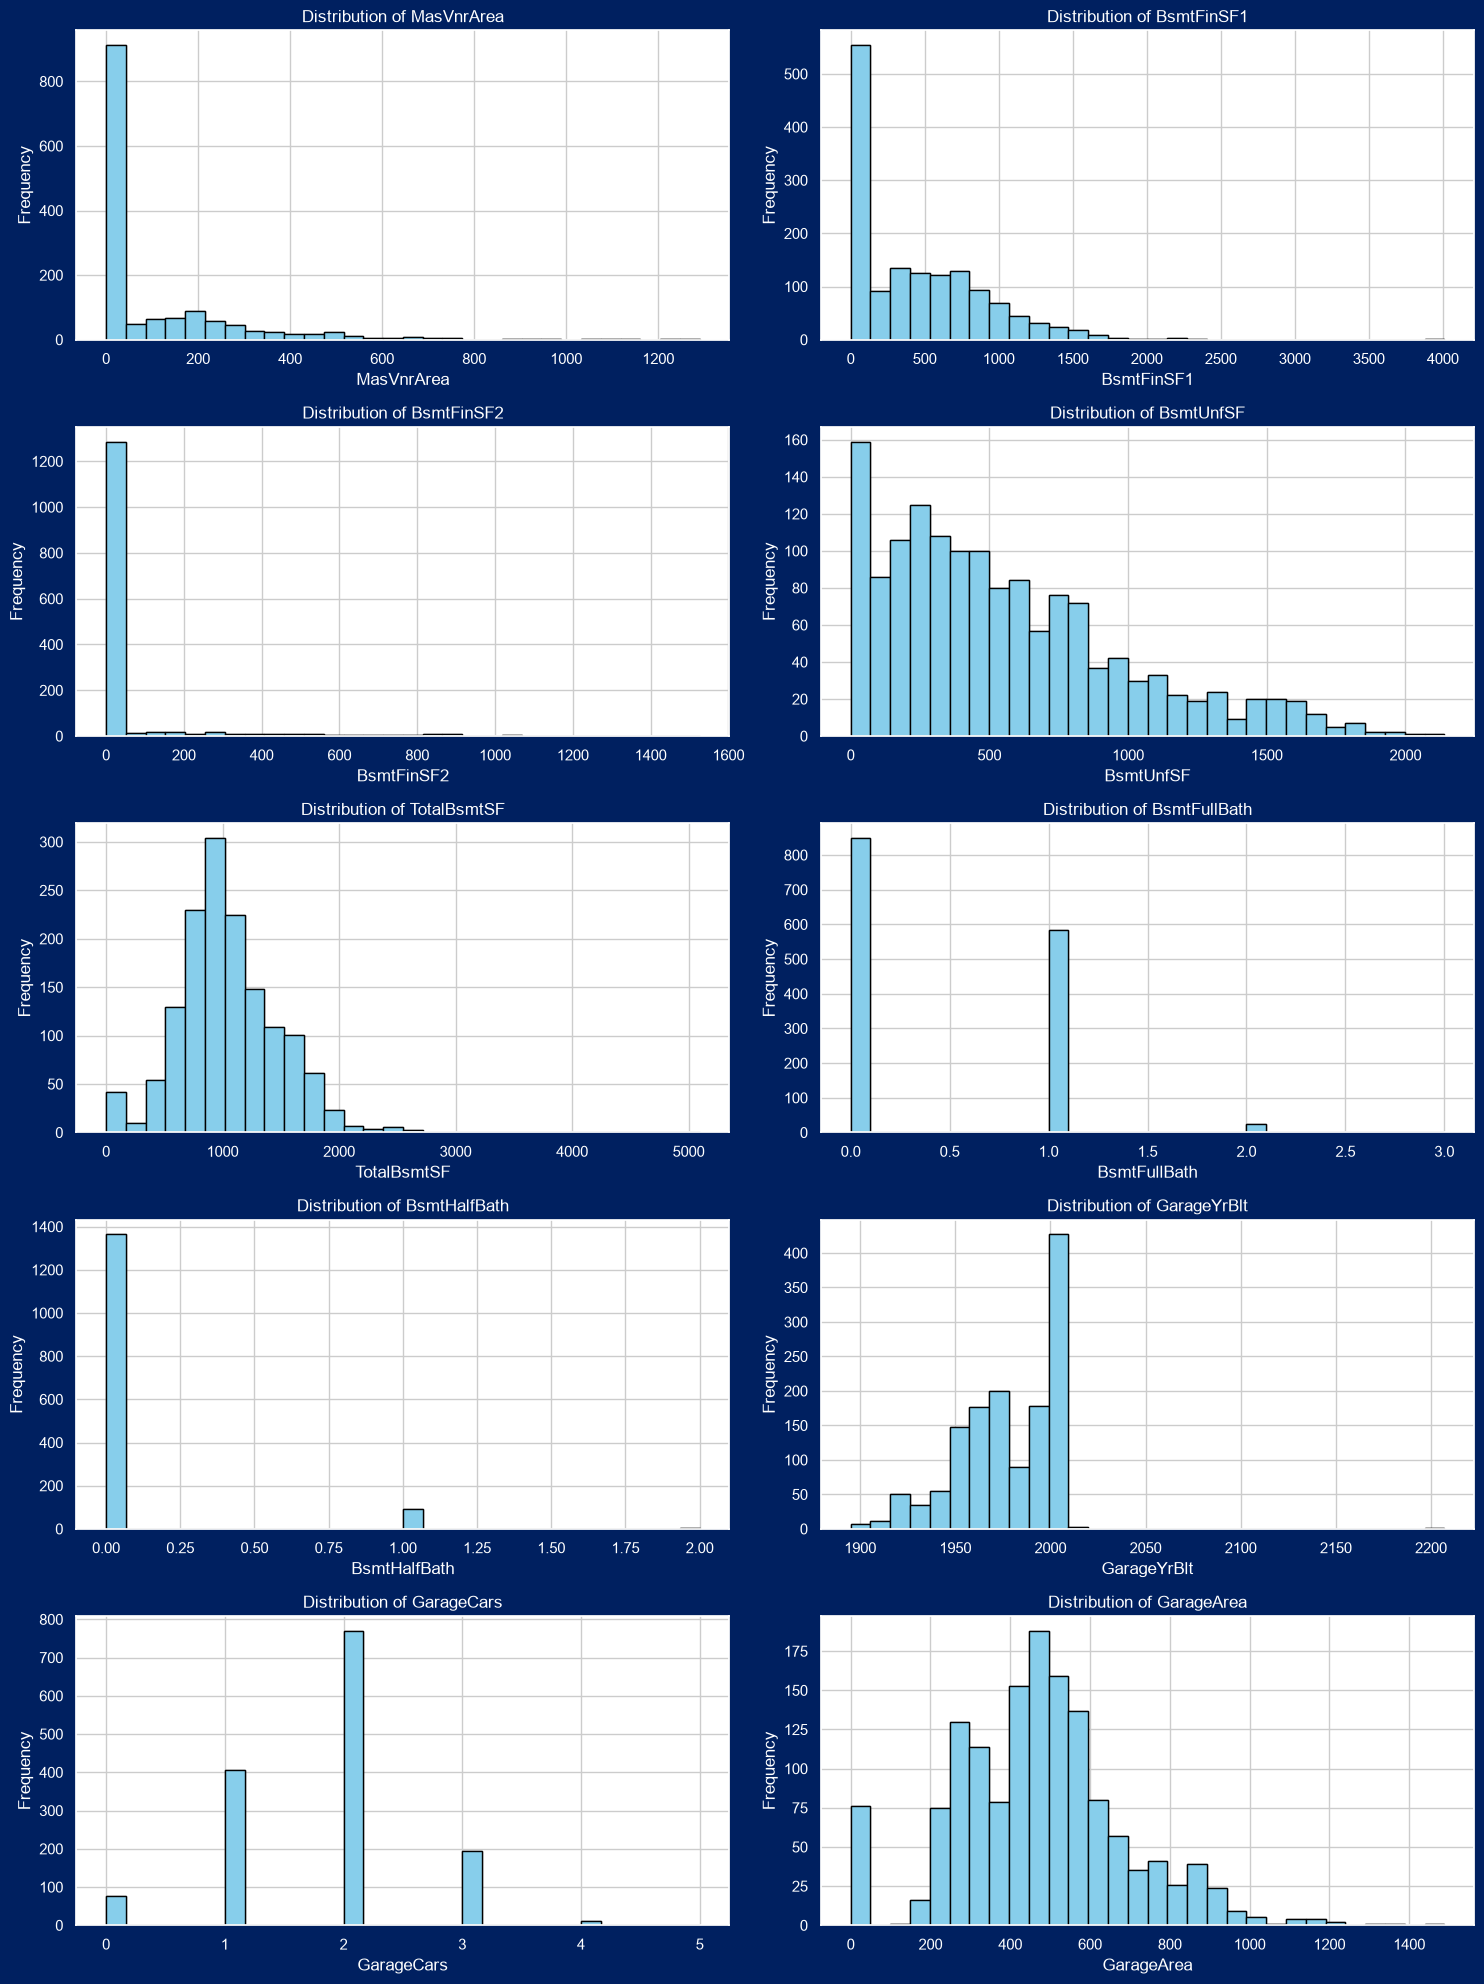

In [315]:
import matplotlib.pyplot as plt

# Assuming df_numeric is your numerical DataFrame
cols = df_numeric.columns
n_cols = 2
n_rows = (len(cols) - 1) // n_cols + 1

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4), facecolor='#002060')
axes = axes.flatten() # Flatten to iterate easily

for i, col in enumerate(cols):
    # Remove NaN values for the specific column to avoid plotting errors
    data = df_numeric[col].dropna()
    
    axes[i].hist(data, bins=30, color='skyblue', edgecolor='black', alpha=0.7)
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

for i, col in enumerate(cols):
    data = df_numeric[col].dropna()
    axes[i].hist(data, bins=30, color='skyblue', edgecolor='black')
    
    # Set Title and Axis Labels to White
    axes[i].set_title(f'Distribution of {col}', color='white')
    axes[i].set_xlabel(col, color='white')
    axes[i].set_ylabel('Frequency', color='white')
    
    # Set the numbers on the axes (ticks) to White
    axes[i].tick_params(axis='x', colors='white')
    axes[i].tick_params(axis='y', colors='white')
    
    # Optional: Change the spine (border) color to white
    for spine in axes[i].spines.values():
        spine.set_edgecolor('white')

plt.tight_layout()
plt.show()



1. "MasVnrArea"  nan to zero
2. "GarageYrBlt" nan to median (non gausian dist)

In [317]:
df['MasVnrArea'] = df['MasVnrArea'].fillna(0)
df['GarageYrBlt'] = df['GarageYrBlt'].fillna(df_numeric['MasVnrArea'].median())

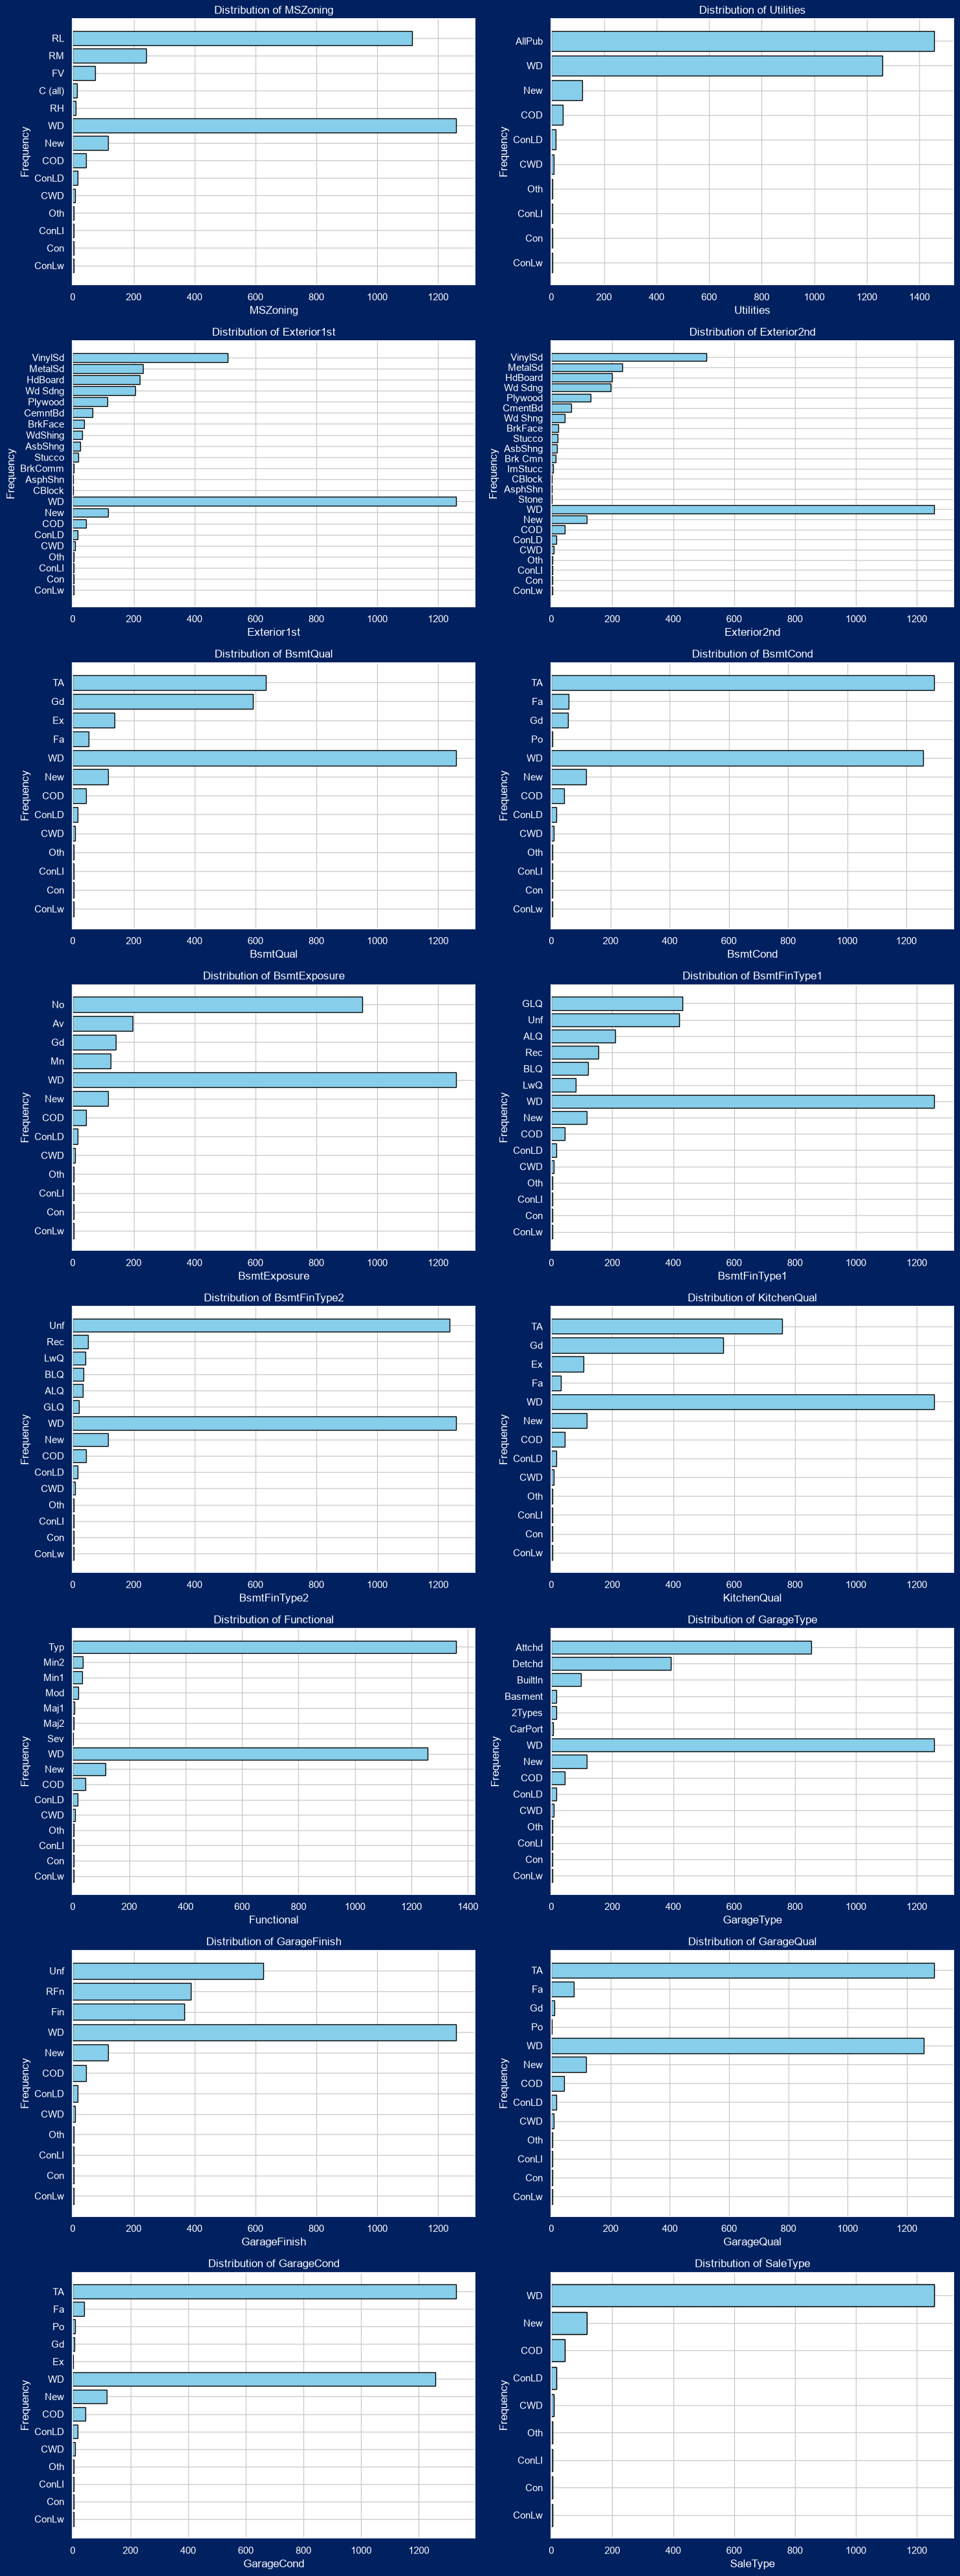

In [318]:
# Assuming df_categorical is your categorical DataFrame
cols = df_categorical.columns
n_cols = 2
n_rows = (len(cols) - 1) // n_cols + 1

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 5),facecolor='#002060')
axes = axes.flatten()

for i, col in enumerate(cols):
    # Get counts and sort them
    counts = df_categorical[col].value_counts()
    
    # Use barh (horizontal) for better label readability
    axes[i].barh(counts.index.astype(str), counts.values, color='skyblue', edgecolor='black')
    axes[i].set_title(f'Count of {col}')
    axes[i].invert_yaxis()  # Put the highest count at the top

# Hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

import matplotlib.pyplot as plt

# ... (setup your subplots as before) ...

for i, col in enumerate(cols):
    data = df_categorical[col].dropna()
    axes[i].barh(counts.index.astype(str), counts.values, color='skyblue', edgecolor='black')
    
    # Set Title and Axis Labels to White
    axes[i].set_title(f'Distribution of {col}', color='white')
    axes[i].set_xlabel(col, color='white')
    axes[i].set_ylabel('Frequency', color='white')
    
    # Set the numbers on the axes (ticks) to White
    axes[i].tick_params(axis='x', colors='white')
    axes[i].tick_params(axis='y', colors='white')
    
    # Optional: Change the spine (border) color to white
    for spine in axes[i].spines.values():
        spine.set_edgecolor('white')

plt.tight_layout()
plt.show()


In [319]:
print(f"Categorical columns: {df_categorical.columns.tolist()}")

Categorical columns: ['MSZoning', 'Utilities', 'Exterior1st', 'Exterior2nd', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'KitchenQual', 'Functional', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'SaleType']


1. Filling every nan value with mode

In [ ]:
df['BsmtQual'] = df['BsmtQual'].fillna(df_categorical['BsmtQual'].mode()[0])
df['BsmtCond'] = df['BsmtCond'].fillna(df_categorical['BsmtCond'].mode()[0])
df['BsmtExposure'] = df['BsmtExposure'].fillna(df_categorical['BsmtExposure'].mode()[0])
df['BsmtFinType1'] = df['BsmtFinType1'].fillna(df_categorical['BsmtFinType1'].mode()[0])
df['BsmtFinType2'] = df['BsmtFinType2'].fillna(df_categorical['BsmtFinType2'].mode()[0])
df['Electrical'] = df['Electrical'].fillna(df_categorical['Electrical'].mode()[0])
df['GarageType'] = df['GarageType'].fillna(df_categorical['GarageType'].mode()[0])
df['GarageFinish'] = df['GarageFinish'].fillna(df_categorical['GarageFinish'].mode()[0])
df['GarageQual'] = df['GarageQual'].fillna(df_categorical['GarageQual'].mode()[0])
df['GarageCond'] = df['GarageCond'].fillna(df_categorical['GarageCond'].mode()[0])

KeyError: 'Electrical'

In [ ]:
null_counts = df.isna().sum()
print(null_counts[null_counts > 0])

LotFrontage    259
MasVnrType     872
FireplaceQu    690
dtype: int64


In [ ]:
# List of specific columns to extract
cols_to_extract = [
    'LotFrontage', 'MasVnrType', 'FireplaceQu'
]

# Create the new dataframe
df_new1 = df[cols_to_extract].copy()

# Preview the result
print(df_new1.head())

   LotFrontage MasVnrType FireplaceQu
0         65.0    BrkFace         NaN
1         80.0        NaN          TA
2         68.0    BrkFace          TA
3         60.0        NaN          Gd
4         84.0    BrkFace          TA


1. Again separating features into numeric and categoric

In [ ]:
df_numeric1 = df_new1.select_dtypes(include=['number'])


df_categorical1 = df_new1.select_dtypes(include=['object', 'category'])

# Verify the splits
print(f"Numerical columns: {df_numeric1.columns.tolist()}")
print(f"Categorical columns: {df_categorical1.columns.tolist()}")

Numerical columns: ['LotFrontage']
Categorical columns: ['MasVnrType', 'FireplaceQu']


C:\Users\DELL\AppData\Local\Temp\ipykernel_20592\4016409077.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df_categorical1 = df_new1.select_dtypes(include=['object', 'category'])


1.Since nan values are significant we will apply Model-based imputation for numeric features


In [ ]:
from sklearn.experimental import enable_iterative_imputer  
from sklearn.impute import IterativeImputer
import pandas as pd

# 1. Select only numerical columns (Imputers require numbers)
numeric_df = df.select_dtypes(include=['number'])

# 2. Initialize the IterativeImputer
# max_iter=10 is standard; random_state ensures consistent results
it_imputer = IterativeImputer(max_iter=10, random_state=42)

# 3. Fit and transform the numeric data
# This calculates the missing values for ALL numeric columns simultaneously
imputed_array = it_imputer.fit_transform(numeric_df)

# 4. Convert the result back to a DataFrame to match indices and columns
df_imputed = pd.DataFrame(imputed_array, columns=numeric_df.columns, index=df.index)

# 5. Update the original dataframe specifically for the target columns
df['LotFrontage'] = df_imputed['LotFrontage']


# Verify
print(df['LotFrontage'].isna().sum())

0


1.Since nan values are significant we will apply KNN based imputation for categoric features


In [ ]:
from sklearn.impute import KNNImputer
from sklearn.preprocessing import OrdinalEncoder
import pandas as pd
import numpy as np

# 1. List of categorical columns to impute
cat_cols = ['MasVnrType', 'FireplaceQu']

# 2. Encode strings to numbers (handling NaNs by keeping them as NaNs)
encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=np.nan)

# We only work on the columns that need imputation
df_cat = df[cat_cols].copy()
df_cat_encoded = encoder.fit_transform(df_cat)

# 3. Apply KNN Imputer
# n_neighbors=1 ensures we pick the "closest" single category type
imputer = KNNImputer(n_neighbors=1)
imputed_encoded = imputer.fit_transform(df_cat_encoded)

# 4. Convert back to original string labels
# We round the values to ensure they match the integer labels the encoder expects
imputed_labels = encoder.inverse_transform(np.round(imputed_encoded))

# 5. Update the original dataframe
df[cat_cols] = imputed_labels

# Verify
print(df[cat_cols].isna().sum())

MasVnrType     0
FireplaceQu    0
dtype: int64


In [ ]:
import pandas as pd

# Feature 1: Total Square Footage 
# Combines above-ground living area (1st + 2nd floor), LowQualFinSF and total basement square footage

df['TotalSF'] = df['1stFlrSF'] + df['2ndFlrSF'] + df['TotalBsmtSF']+df['LowQualFinSF']

# Feature 2: House Age at Time of Sale
# Calculates exactly how old the structure was when the transaction occurred
df['HouseAge'] = df['YrSold'] - df['YearBuilt']

#Years Since Last Remodel
# Captures if a house is old but was recently modernized
df['YearsSinceRemodel'] = df['YrSold'] - df['YearRemodAdd']

# Total Bathrooms
# Combines full and half baths across the basement and upper floors
df['TotalBathrooms'] = (df['FullBath'] + (0.5 * df['HalfBath']) + df['BsmtFullBath'] + (0.5 * df['BsmtHalfBath'])
)


# Verify the newly created features
new_cols = ['TotalSF', 'HouseAge', 'YearsSinceRemodel', 'TotalBathrooms']
print("Sample of newly engineered features:")
print(df[new_cols].head())

Sample of newly engineered features:
   TotalSF  HouseAge  YearsSinceRemodel  TotalBathrooms
0     2566         5                  5             3.5
1     2524        31                 31             2.5
2     2706         7                  6             3.5
3     2473        91                 36             2.0
4     3343         8                  8             3.5


In [ ]:
# List the parent columns that are now redundant
columns_to_drop = [
    '1stFlrSF', '2ndFlrSF','BsmtFinSF1','BsmtFinSF2', 'TotalBsmtSF', # Replaced by TotalSF
    'YearBuilt', 'YrSold',                 # Replaced by HouseAge / YearsSinceRemodel
    'YearRemodAdd',                        # Replaced by YearsSinceRemodel
    'FullBath', 'HalfBath',                # Replaced by TotalBathrooms
    'BsmtFullBath', 'BsmtHalfBath'         # Replaced by TotalBathrooms
]

# Drop them safely, ignoring errors just in case you already dropped some earlier
df = df.drop(columns=columns_to_drop, errors='ignore')

# Double check your final column list
print("Remaining columns in pipeline:")
print(df.columns.tolist())

Remaining columns in pipeline:
['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'OverallQual', 'OverallCond', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'BsmtUnfSF', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'LowQualFinSF', 'GrLivArea', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType', 'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond', 'PavedDrive', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'SaleType', 'SaleCondition', 'SalePrice', 'TotalSF', 'HouseAge', 'YearsSinceRemodel', 'TotalBathrooms']


1.Conducting Correlation

In [ ]:
# 1. Calculate the correlation matrix
corr_matrix = df.corr(numeric_only=True)

# 2. Mask the upper triangle of the matrix with True values
# np.triu creates a matrix of boolean values for the upper half
mask = np.triu(np.ones(corr_matrix.shape), k=0).astype(bool)

# 3. Apply the mask to keep only the bottom-left triangle, then unstack
# This drops self-correlation (k=0) and all mirror duplicates automatically
corr_pairs = corr_matrix.where(~mask).unstack().dropna()

# 4. Filter for strong correlations (|r| >= 0.8)
strong_corr_unique = corr_pairs[(corr_pairs >= 0.8) | (corr_pairs <= -0.8)]

print("Unique Strong Correlations (|r| >= 0.8):")
if not strong_corr_unique.empty:
    print(strong_corr_unique.sort_values(ascending=False))
else:
    print("No features found in those correlation ranges.")

Unique Strong Correlations (|r| >= 0.8):
GarageCars  GarageArea      0.882475
GrLivArea   TotalSF         0.880324
            TotRmsAbvGrd    0.825489
dtype: float64


In [ ]:
cols_to_remove = ["GarageCars","GrLivArea","TotRmsAbvGrd", 'Id']

df= df.drop(columns=cols_to_remove)

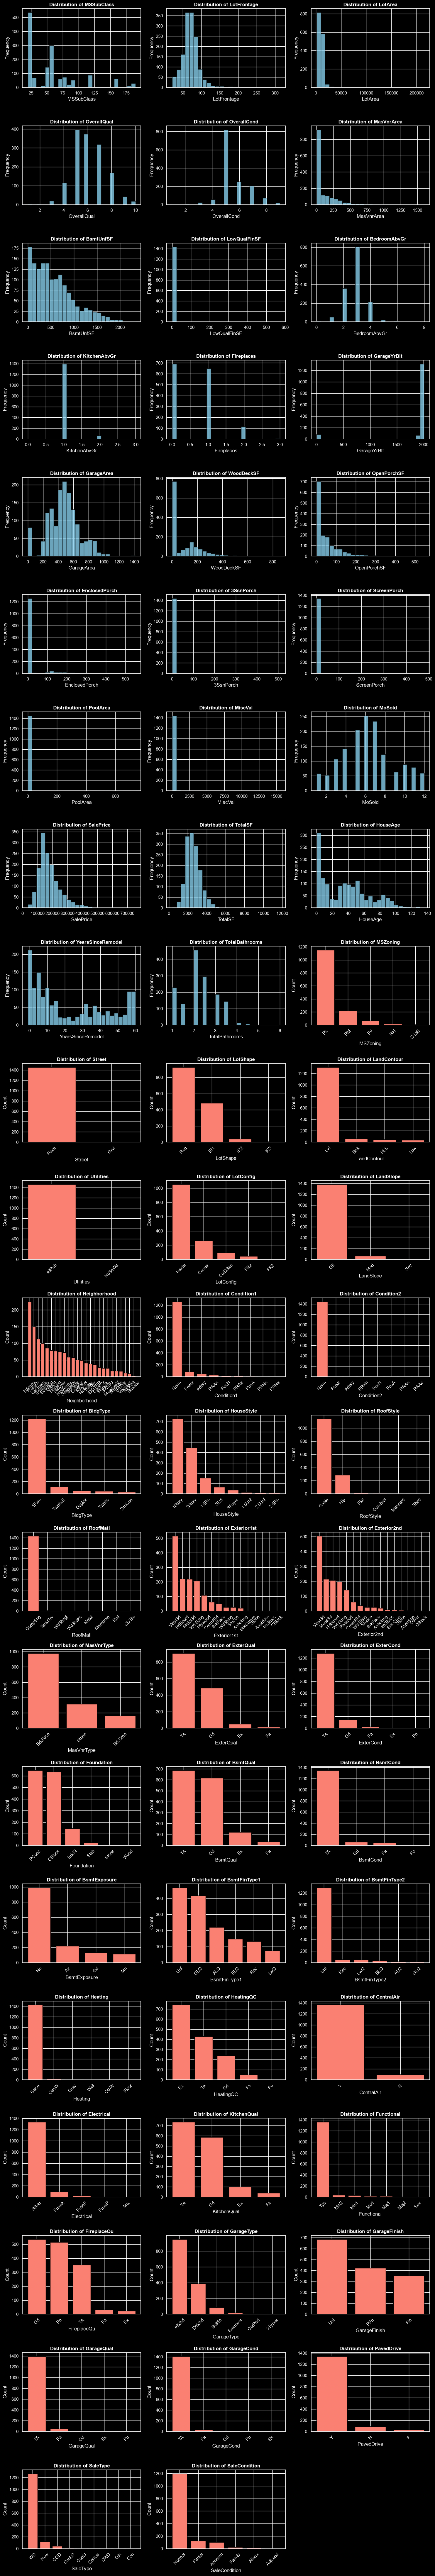

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Separate your columns by type
numeric_cols = df.select_dtypes(include=['number']).columns
categorical_cols = df.select_dtypes(exclude=['number']).columns
all_features = list(numeric_cols) + list(categorical_cols)

# 2. Setup the grid layout (3 columns wide)
n_cols = 3
n_rows = (len(all_features) + n_cols - 1) // n_cols

# Use a dark background style to make white labels pop, 
# or set manually if you prefer a custom background.
plt.style.use('dark_background') 

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
axes = axes.flatten() # Makes the grid easy to loop through

for i, col in enumerate(all_features):
    ax = axes[i]
    
    if col in numeric_cols:
        # NUMERIC: Plot a Histogram
        ax.hist(df[col].dropna(), bins=25, color='skyblue', edgecolor='black', alpha=0.8)
        ax.set_ylabel('Frequency', color='white')
    else:
        # CATEGORICAL: Plot a Bar Chart
        counts = df[col].value_counts()
        ax.bar(counts.index.astype(str), counts.values, color='salmon', edgecolor='black')
        ax.set_ylabel('Count', color='white')
        # Rotate x-labels if they are categorical strings
        ax.tick_params(axis='x', rotation=45)

    # Styling labels to WHITE
    ax.set_title(f'Distribution of {col}', color='white', fontsize=12, fontweight='bold')
    ax.set_xlabel(col, color='white')
    ax.tick_params(colors='white') # Changes tick numbers to white
    
    # Optional: Make the plot border (spines) white
    for spine in ax.spines.values():
        spine.set_edgecolor('white')

# 3. Clean up empty subplots (if features don't fill the last row perfectly)
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
cols_to_remove = ["GarageCond","GarageQual","Street","Utilities", "Condition2", 'RoofMatl', "Heating","LowQualFinSF","KitchenAbvGr","EnclosedPorch","3SsnPorch","ScreenPorch","PoolArea","MiscVal"]

df.drop(columns=cols_to_remove)

,MSSubClass,MSZoning,LotFrontage,LotArea,LotShape,LandContour,LotConfig,LandSlope,Neighborhood,Condition1,...,WoodDeckSF,OpenPorchSF,MoSold,SaleType,SaleCondition,SalePrice,TotalSF,HouseAge,YearsSinceRemodel,TotalBathrooms
0,60,RL,65.0,8450,Reg,Lvl,Inside,Gtl,CollgCr,Norm,...,0,61,2,WD,Normal,208500,2566,5,5,3.5
1,20,RL,80.0,9600,Reg,Lvl,FR2,Gtl,Veenker,Feedr,...,298,0,5,WD,Normal,181500,2524,31,31,2.5
2,60,RL,68.0,11250,IR1,Lvl,Inside,Gtl,CollgCr,Norm,...,0,42,9,WD,Normal,223500,2706,7,6,3.5
3,70,RL,60.0,9550,IR1,Lvl,Corner,Gtl,Crawfor,Norm,...,0,35,2,WD,Abnorml,140000,2473,91,36,2.0
4,60,RL,84.0,14260,IR1,Lvl,FR2,Gtl,NoRidge,Norm,...,192,84,12,WD,Normal,250000,3343,8,8,3.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,60,RL,62.0,7917,Reg,Lvl,Inside,Gtl,Gilbert,Norm,...,0,40,8,WD,Normal,175000,2600,8,7,2.5
1456,20,RL,85.0,13175,Reg,Lvl,Inside,Gtl,NWAmes,Norm,...,349,0,2,WD,Normal,210000,3615,32,22,3.0
1457,70,RL,66.0,9042,Reg,Lvl,Inside,Gtl,Crawfor,Norm,...,0,60,5,WD,Normal,266500,3492,69,4,2.0
1458,20,RL,68.0,9717,Reg,Lvl,Inside,Gtl,NAmes,Norm,...,366,0,4,WD,Normal,142125,2156,60,14,2.0


1. Scaling

In [ ]:
df4=df.copy()

Conducting StandardScaler Scaling

In [ ]:
from sklearn.preprocessing import StandardScaler
numeric_cols = df4.select_dtypes(include=['number']).columns
cols_to_scale = [col for col in numeric_cols if col != 'SalePrice']

# 2. Initialize the StandardScaler (centers data around Mean=0, Std=1)
scaler = StandardScaler()

# 3. Fit and Transform ONLY the selected numerical data
df_standard_scaled = df4.copy()
df_standard_scaled[cols_to_scale] = scaler.fit_transform(df4[cols_to_scale])

# 4. Verify the scaling statistics for the modified columns
print("Mean values after scaling (Target is approximately 0.0):")
# Using round() because floating-point math might show numbers very close to 0 (e.g., 1e-16)
print(df_standard_scaled[cols_to_scale].mean().round(4).head())

print("\nStandard Deviation after scaling (Target is exactly 1.0):")
print(df_standard_scaled[cols_to_scale].std().round(4).head())

Mean values after scaling (Target is approximately 0.0):
MSSubClass    -0.0
LotFrontage   -0.0
LotArea       -0.0
OverallQual    0.0
OverallCond    0.0
dtype: float64

Standard Deviation after scaling (Target is exactly 1.0):
MSSubClass     1.0003
LotFrontage    1.0003
LotArea        1.0003
OverallQual    1.0003
OverallCond    1.0003
dtype: float64


1. Conducting MinMaxScaler

In [ ]:
from sklearn.preprocessing import MinMaxScaler
import pandas as pd

# 1. Identify numerical columns BUT exclude 'SalePrice'
numeric_cols = df4.select_dtypes(include=['number']).columns
cols_to_scale = [col for col in numeric_cols if col != 'SalePrice']

# 2. Initialize the MinMaxScaler (scales data strictly between 0 and 1)
scaler = MinMaxScaler()

# 3. Fit and Transform ONLY the selected numerical data
df_minmax_scaled = df4.copy()
df_minmax_scaled[cols_to_scale] = scaler.fit_transform(df4[cols_to_scale])

# 4. Verify the scaling boundaries for the modified columns
print("Min values after scaling (Target is 0.0):")
print(df_minmax_scaled[cols_to_scale].min().sort_values())

print("\nMax values after scaling (Target is 1.0):")
print(df_minmax_scaled[cols_to_scale].max().sort_values())

# Verify SalePrice was left completely unscaled
print(f"\nSalePrice Range: {df_minmax_scaled['SalePrice'].min()} to {df_minmax_scaled['SalePrice'].max()}")

Min values after scaling (Target is 0.0):
MSSubClass           0.0
LotFrontage          0.0
LotArea              0.0
OverallQual          0.0
OverallCond          0.0
MasVnrArea           0.0
BsmtUnfSF            0.0
LowQualFinSF         0.0
BedroomAbvGr         0.0
KitchenAbvGr         0.0
Fireplaces           0.0
GarageYrBlt          0.0
GarageArea           0.0
WoodDeckSF           0.0
OpenPorchSF          0.0
EnclosedPorch        0.0
3SsnPorch            0.0
ScreenPorch          0.0
PoolArea             0.0
MiscVal              0.0
MoSold               0.0
TotalSF              0.0
HouseAge             0.0
YearsSinceRemodel    0.0
TotalBathrooms       0.0
dtype: float64

Max values after scaling (Target is 1.0):
LotArea              1.0
GarageYrBlt          1.0
WoodDeckSF           1.0
MoSold               1.0
OverallCond          1.0
MasVnrArea           1.0
LotFrontage          1.0
MSSubClass           1.0
LowQualFinSF         1.0
BsmtUnfSF            1.0
KitchenAbvGr         1.0


Conducting Yeo-Johnson Transforming for Gaussian distribution

In [ ]:
from sklearn.preprocessing import PowerTransformer
import pandas as pd

# 1. Identify numerical columns BUT exclude 'SalePrice'
numeric_cols = df_standard_scaled.select_dtypes(include=['number']).columns
cols_to_transform = [col for col in numeric_cols if col != 'SalePrice']

# 2. Initialize the PowerTransformer with the 'yeo-johnson' method
pt = PowerTransformer(method='yeo-johnson', standardize=False)

# 3. Fit and Transform ONLY the selected numerical data
# We create a copy to keep the original dataframe intact
df_transformed_standard_scaled = df_standard_scaled.copy()
df_transformed_standard_scaled[cols_to_transform] = pt.fit_transform(df_standard_scaled[cols_to_transform])

# 4. Check the new skewness of the transformed columns
new_skew = df_transformed_standard_scaled[cols_to_transform].skew().sort_values(ascending=False)
print("New Skewness after Yeo-Johnson (Target is 0):")
print(new_skew)

# Verify SalePrice was left completely unscaled
print("\nOriginal SalePrice Mean:", df4['SalePrice'].mean())
print("Transformed DataFrame SalePrice Mean:", df_transformed_standard_scaled['SalePrice'].mean())

New Skewness after Yeo-Johnson (Target is 0):
PoolArea             14.352680
3SsnPorch             7.613746
LowQualFinSF          7.299413
MiscVal               5.016996
ScreenPorch           3.113276
EnclosedPorch         2.053944
MasVnrArea            0.673451
WoodDeckSF            0.400827
OpenPorchSF           0.370393
MSSubClass            0.222993
Fireplaces            0.215296
YearsSinceRemodel     0.192109
HouseAge              0.129779
BedroomAbvGr          0.120203
BsmtUnfSF             0.096754
TotalBathrooms        0.030234
GarageArea            0.019970
LotFrontage           0.007653
TotalSF               0.004947
MoSold               -0.012439
OverallQual          -0.036970
LotArea              -0.267855
OverallCond          -0.328936
GarageYrBlt          -1.293295
KitchenAbvGr         -8.573974
dtype: float64

Original SalePrice Mean: 180921.19589041095
Transformed DataFrame SalePrice Mean: 180921.19589041095


In [ ]:
from sklearn.preprocessing import PowerTransformer
import pandas as pd

# 1. Identify numerical columns BUT exclude 'SalePrice'
numeric_cols = df_minmax_scaled.select_dtypes(include=['number']).columns
cols_to_transform = [col for col in numeric_cols if col != 'SalePrice']

# 2. Initialize the PowerTransformer with the 'yeo-johnson' method
pt = PowerTransformer(method='yeo-johnson', standardize=False)

# 3. Fit and Transform ONLY the selected numerical data
# We create a copy to keep the original dataframe intact
df_transformed_minmax_scaled = df_standard_scaled.copy()
df_transformed_minmax_scaled[cols_to_transform] = pt.fit_transform(df_standard_scaled[cols_to_transform])

# 4. Check the new skewness of the transformed columns
new_skew = df_transformed_minmax_scaled[cols_to_transform].skew().sort_values(ascending=False)
print("New Skewness after Yeo-Johnson (Target is 0):")
print(new_skew)

# Verify SalePrice was left completely unscaled
print("\nOriginal SalePrice Mean:", df4['SalePrice'].mean())
print("Transformed DataFrame SalePrice Mean:", df_transformed_minmax_scaled['SalePrice'].mean())

New Skewness after Yeo-Johnson (Target is 0):
PoolArea             14.352680
3SsnPorch             7.613746
LowQualFinSF          7.299413
MiscVal               5.016996
ScreenPorch           3.113276
EnclosedPorch         2.053944
MasVnrArea            0.673451
WoodDeckSF            0.400827
OpenPorchSF           0.370393
MSSubClass            0.222993
Fireplaces            0.215296
YearsSinceRemodel     0.192109
HouseAge              0.129779
BedroomAbvGr          0.120203
BsmtUnfSF             0.096754
TotalBathrooms        0.030234
GarageArea            0.019970
LotFrontage           0.007653
TotalSF               0.004947
MoSold               -0.012439
OverallQual          -0.036970
LotArea              -0.267855
OverallCond          -0.328936
GarageYrBlt          -1.293295
KitchenAbvGr         -8.573974
dtype: float64

Original SalePrice Mean: 180921.19589041095
Transformed DataFrame SalePrice Mean: 180921.19589041095


In [ ]:
summary_df = pd.DataFrame({
    'Min': df_transformed_minmax_scaled[cols_to_scale].min(),
    'Max': df_transformed_minmax_scaled[cols_to_scale].max()
})

print(summary_df)

                         Min       Max
MSSubClass         -1.259392  1.409524
LotFrontage        -2.769584  5.698519
LotArea            -1.546608  1.911168
OverallQual        -4.207938  2.530308
OverallCond        -6.100255  2.259935
MasVnrArea         -0.982836  0.836036
BsmtUnfSF          -1.748353  2.192811
LowQualFinSF       -0.842678  0.038033
BedroomAbvGr       -3.606712  6.074411
KitchenAbvGr      -14.273159  2.542175
Fireplaces         -1.143514  2.369477
GarageYrBlt        -0.232662  0.716580
GarageArea         -2.313465  4.131548
WoodDeckSF         -1.117275  1.578930
OpenPorchSF        -1.106860  1.350236
EnclosedPorch      -0.892829  0.247153
3SsnPorch          -0.832603  0.036458
ScreenPorch        -0.814180  0.147833
PoolArea           -0.757993  0.018168
MiscVal            -0.351888  0.037601
MoSold             -2.164825  1.906691
TotalSF            -3.982259  5.267608
HouseAge           -1.508400  2.174216
YearsSinceRemodel  -1.552912  1.239011
TotalBathrooms     -1.671

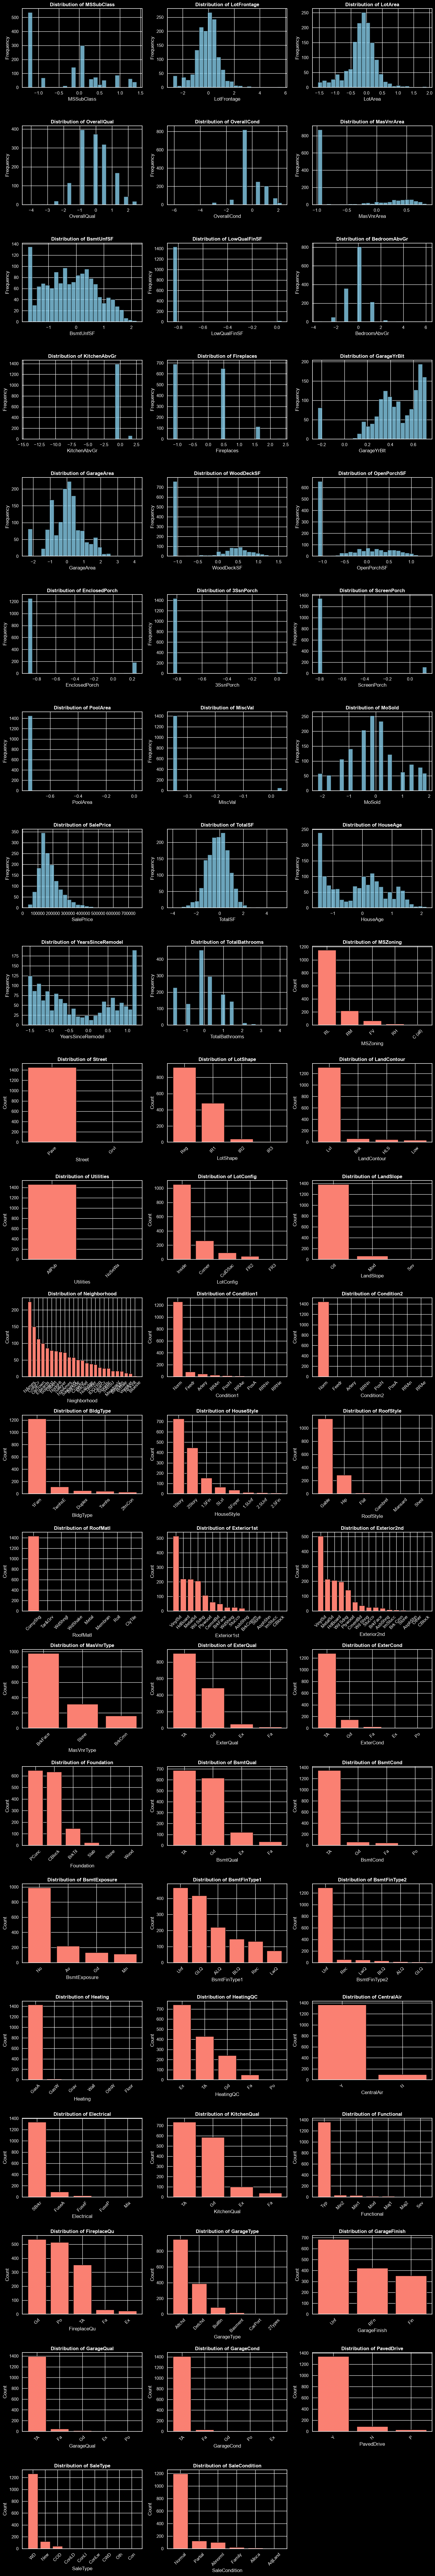

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Separate your columns by type
numeric_cols = df_transformed_standard_scaled.select_dtypes(include=['number']).columns
categorical_cols = df_transformed_standard_scaled.select_dtypes(exclude=['number']).columns
all_features = list(numeric_cols) + list(categorical_cols)

# 2. Setup the grid layout (3 columns wide)
n_cols = 3
n_rows = (len(all_features) + n_cols - 1) // n_cols

# Use a dark background style to make white labels pop, 
# or set manually if you prefer a custom background.
plt.style.use('dark_background') 

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
axes = axes.flatten() # Makes the grid easy to loop through

for i, col in enumerate(all_features):
    ax = axes[i]
    
    if col in numeric_cols:
        # NUMERIC: Plot a Histogram
        ax.hist(df_transformed_standard_scaled[col].dropna(), bins=25, color='skyblue', edgecolor='black', alpha=0.8)
        ax.set_ylabel('Frequency', color='white')
    else:
        # CATEGORICAL: Plot a Bar Chart
        counts =df_transformed_standard_scaled[col].value_counts()
        ax.bar(counts.index.astype(str), counts.values, color='salmon', edgecolor='black')
        ax.set_ylabel('Count', color='white')
        # Rotate x-labels if they are categorical strings
        ax.tick_params(axis='x', rotation=45)

    # Styling labels to WHITE
    ax.set_title(f'Distribution of {col}', color='white', fontsize=12, fontweight='bold')
    ax.set_xlabel(col, color='white')
    ax.tick_params(colors='white') # Changes tick numbers to white
    
    # Optional: Make the plot border (spines) white
    for spine in ax.spines.values():
        spine.set_edgecolor('white')

# 3. Clean up empty subplots (if features don't fill the last row perfectly)
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

1. Plotting for MinMaxScaler 

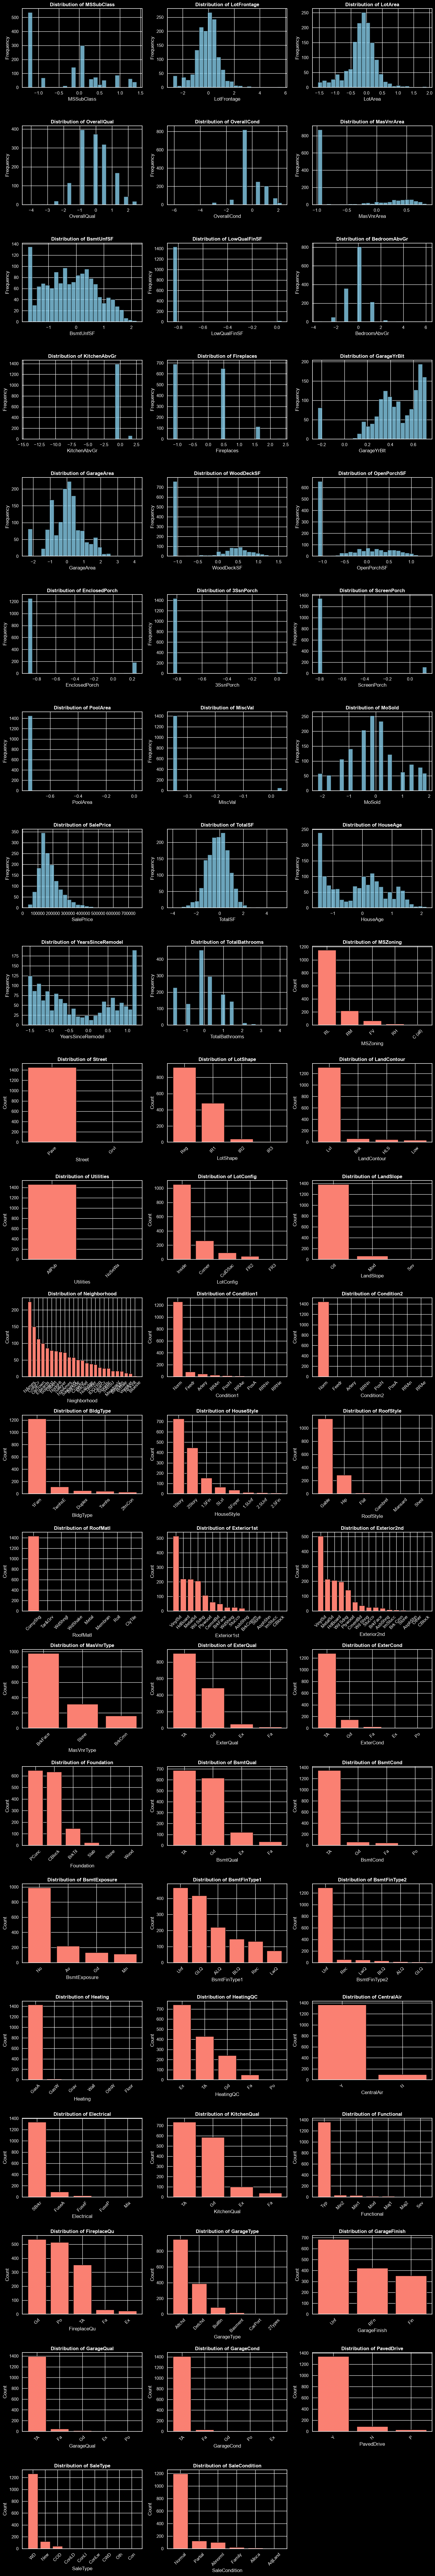

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Separate your columns by type
numeric_cols = df_transformed_minmax_scaled.select_dtypes(include=['number']).columns
categorical_cols = df_transformed_minmax_scaled.select_dtypes(exclude=['number']).columns
all_features = list(numeric_cols) + list(categorical_cols)

# 2. Setup the grid layout (3 columns wide)
n_cols = 3
n_rows = (len(all_features) + n_cols - 1) // n_cols

# Use a dark background style to make white labels pop, 
# or set manually if you prefer a custom background.
plt.style.use('dark_background') 

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
axes = axes.flatten() # Makes the grid easy to loop through

for i, col in enumerate(all_features):
    ax = axes[i]
    
    if col in numeric_cols:
        # NUMERIC: Plot a Histogram
        ax.hist(df_transformed_minmax_scaled[col].dropna(), bins=25, color='skyblue', edgecolor='black', alpha=0.8)
        ax.set_ylabel('Frequency', color='white')
    else:
        # CATEGORICAL: Plot a Bar Chart
        counts =df_transformed_minmax_scaled[col].value_counts()
        ax.bar(counts.index.astype(str), counts.values, color='salmon', edgecolor='black')
        ax.set_ylabel('Count', color='white')
        # Rotate x-labels if they are categorical strings
        ax.tick_params(axis='x', rotation=45)

    # Styling labels to WHITE
    ax.set_title(f'Distribution of {col}', color='white', fontsize=12, fontweight='bold')
    ax.set_xlabel(col, color='white')
    ax.tick_params(colors='white') # Changes tick numbers to white
    
    # Optional: Make the plot border (spines) white
    for spine in ax.spines.values():
        spine.set_edgecolor('white')

# 3. Clean up empty subplots (if features don't fill the last row perfectly)
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

1. One Hot Encoding

In [ ]:
df_encoded_standard = pd.get_dummies(df_transformed_standard_scaled, drop_first=True, dtype=int)

print(df_encoded_standard.head())

   MSSubClass  LotFrontage   LotArea  OverallQual  OverallCond  MasVnrArea  \
0    0.070775    -0.250534 -0.236484     0.628127    -0.562290    0.333653   
1   -1.259392     0.377651 -0.097590    -0.072178     1.701699   -0.982836   
2    0.070775    -0.113624  0.070064     0.628127    -0.562290    0.242824   
3    0.269449    -0.490759 -0.103244     0.628127    -0.562290   -0.982836   
4    0.070775     0.525394  0.302033     1.286777    -0.562290    0.558486   

   BsmtUnfSF  LowQualFinSF  BedroomAbvGr  KitchenAbvGr  ...  SaleType_ConLI  \
0  -1.202425     -0.842678      0.163430     -0.231676  ...               0   
1  -0.763189     -0.842678      0.163430     -0.231676  ...               0   
2  -0.329539     -0.842678      0.163430     -0.231676  ...               0   
3  -0.062867     -0.842678      0.163430     -0.231676  ...               0   
4  -0.184368     -0.842678      1.371172     -0.231676  ...               0   

   SaleType_ConLw  SaleType_New  SaleType_Oth  SaleType_

In [ ]:
df_encoded_minmax = pd.get_dummies(df_transformed_minmax_scaled, drop_first=True, dtype=int)

print(df_encoded_minmax.head())

   MSSubClass  LotFrontage   LotArea  OverallQual  OverallCond  MasVnrArea  \
0    0.070775    -0.250534 -0.236484     0.628127    -0.562290    0.333653   
1   -1.259392     0.377651 -0.097590    -0.072178     1.701699   -0.982836   
2    0.070775    -0.113624  0.070064     0.628127    -0.562290    0.242824   
3    0.269449    -0.490759 -0.103244     0.628127    -0.562290   -0.982836   
4    0.070775     0.525394  0.302033     1.286777    -0.562290    0.558486   

   BsmtUnfSF  LowQualFinSF  BedroomAbvGr  KitchenAbvGr  ...  SaleType_ConLI  \
0  -1.202425     -0.842678      0.163430     -0.231676  ...               0   
1  -0.763189     -0.842678      0.163430     -0.231676  ...               0   
2  -0.329539     -0.842678      0.163430     -0.231676  ...               0   
3  -0.062867     -0.842678      0.163430     -0.231676  ...               0   
4  -0.184368     -0.842678      1.371172     -0.231676  ...               0   

   SaleType_ConLw  SaleType_New  SaleType_Oth  SaleType_

In [ ]:
df_encoded_standard["SalePrice"]

0       208500
1       181500
2       223500
3       140000
4       250000
         ...  
1455    175000
1456    210000
1457    266500
1458    142125
1459    147500
Name: SalePrice, Length: 1460, dtype: int64

In [ ]:
df_encoded_minmax["SalePrice"]

0       208500
1       181500
2       223500
3       140000
4       250000
         ...  
1455    175000
1456    210000
1457    266500
1458    142125
1459    147500
Name: SalePrice, Length: 1460, dtype: int64

Deriving new Categoric Feature based 'SalePrice' with ['Budget', 'Standard', 'Premium'] categories

1. Equal Frequency Binning

--- Calculated Equal-Frequency (Quantile) Bin Edges ---
Min (0th percentile):       $34,900
33.3rd percentile edge:     $139,700
66.6th percentile edge:     $190,000
Max (100th percentile):     $755,000


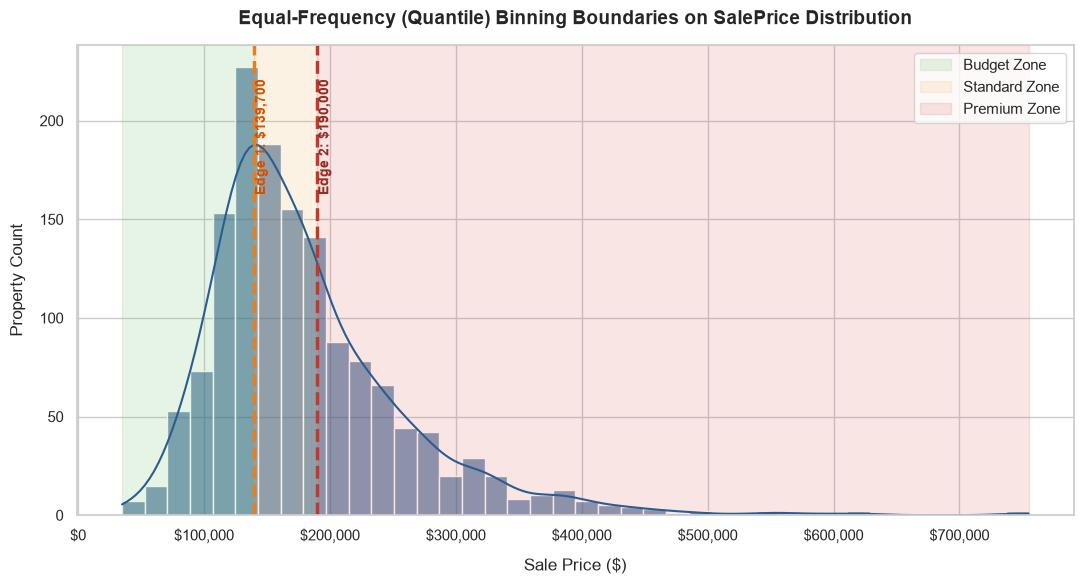

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calculate the exact quantile bin edges (0th, 33.3rd, 66.6th, and 100th percentiles)
# pd.qcut uses these behind the scenes to create 3 equal-frequency bins
quantiles = [0, 1/3, 2/3, 1]
bin_edges = df_encoded_standard['SalePrice'].quantile(quantiles).values

print("--- Calculated Equal-Frequency (Quantile) Bin Edges ---")
print(f"Min (0th percentile):       ${round(bin_edges[0]):,}")
print(f"33.3rd percentile edge:     ${round(bin_edges[1]):,}")
print(f"66.6th percentile edge:     ${round(bin_edges[2]):,}")
print(f"Max (100th percentile):     ${round(bin_edges[3]):,}")

# 2. Plotting the histogram with the calculated bin edges
sns.set_theme(style="whitegrid")
plt.figure(figsize=(11, 6))

# Plot baseline histogram and smooth distribution line
sns.histplot(
    data=df_encoded_standard, 
    x='SalePrice', 
    kde=True, 
    bins=40, 
    color='#2b5c8f', 
    edgecolor='white',
    alpha=0.6
)

# Color palettes for shading the regions
colors = ['#5cb85c', '#f0ad4e', '#d9534f']  # Green, Orange, Red
labels = ['Budget', 'Standard', 'Premium']

# Shading the background regions based on the computed bin edges
for i in range(3):
    plt.axvspan(bin_edges[i], bin_edges[i+1], color=colors[i], alpha=0.15, label=f'{labels[i]} Zone')
    
# Draw sharp vertical boundary lines between the categories
# Draw sharp vertical boundary lines between the categories
plt.axvline(bin_edges[1], color='#e67e22', linestyle='--', linewidth=2.5)
plt.axvline(bin_edges[2], color='#c0392b', linestyle='--', linewidth=2.5)

# Annotate the specific edge values explicitly onto the plot canvas
plt.text(bin_edges[1], plt.gca().get_ylim()[1]*0.8, f' Edge 1: ${round(bin_edges[1]):,}', 
         color='#d35400', weight='bold', fontsize=10, rotation=90, va='center')
plt.text(bin_edges[2], plt.gca().get_ylim()[1]*0.8, f' Edge 2: ${round(bin_edges[2]):,}', 
         color='#962d22', weight='bold', fontsize=10, rotation=90, va='center')

# Format axes and labels
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"${x:,.0f}"))
plt.title('Equal-Frequency (Quantile) Binning Boundaries on SalePrice Distribution', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Sale Price ($)', fontsize=12, labelpad=10)
plt.ylabel('Property Count', fontsize=12, labelpad=10)

plt.legend(loc='upper right', fontsize=11)
plt.tight_layout()
plt.show()

2. Equal-Width Binning

--- Calculated Equal-Width Bin Edges ---
Min (Lower Bound):        $34,900
Budget/Standard Edge:     $274,933
Standard/Premium Edge:    $514,967
Max (Upper Bound):        $755,000


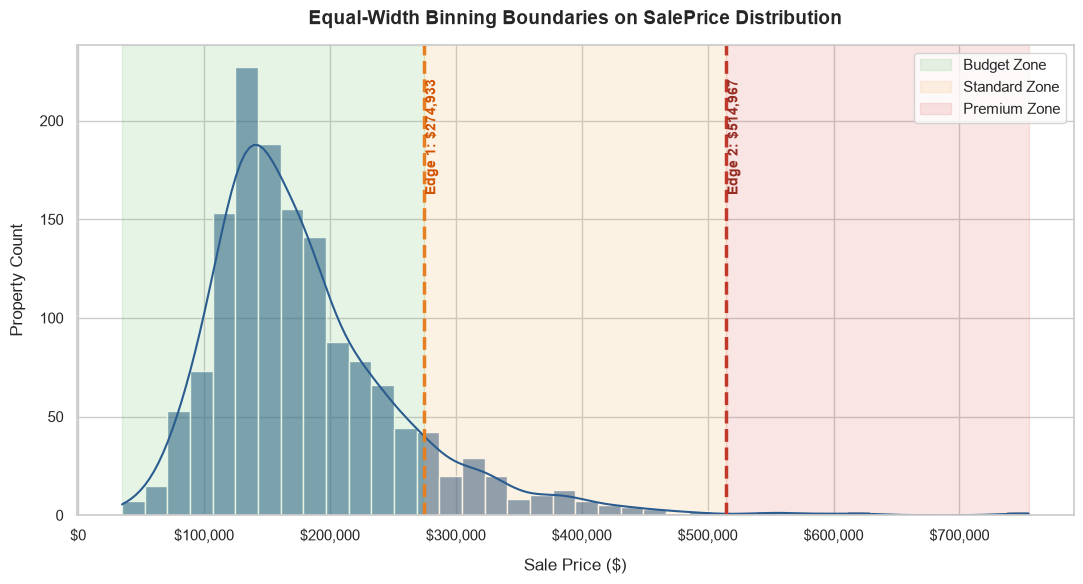

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calculate the exact equal-width bin edges
# pd.cut splits the absolute range (Max - Min) into equal intervals
min_price = df_encoded_standard['SalePrice'].min()
max_price = df_encoded_standard['SalePrice'].max()

# np.linspace calculates 3 intervals, requiring 4 boundary points
bin_edges = np.linspace(min_price, max_price, 4)

print("--- Calculated Equal-Width Bin Edges ---")
print(f"Min (Lower Bound):        ${round(bin_edges[0]):,}")
print(f"Budget/Standard Edge:     ${round(bin_edges[1]):,}")
print(f"Standard/Premium Edge:    ${round(bin_edges[2]):,}")
print(f"Max (Upper Bound):        ${round(bin_edges[3]):,}")

# 2. Plotting the histogram with the calculated bin edges
sns.set_theme(style="whitegrid")
plt.figure(figsize=(11, 6))

# Plot baseline histogram and smooth distribution line
sns.histplot(
    data=df_encoded_standard, 
    x='SalePrice', 
    kde=True, 
    bins=40, 
    color='#2b5c8f', 
    edgecolor='white',
    alpha=0.6
)

# Color palettes for shading the regions
colors = ['#5cb85c', '#f0ad4e', '#d9534f']  # Green, Orange, Red
labels = ['Budget', 'Standard', 'Premium']

# Shade the background regions based on the computed equal-width bin edges
for i in range(3):
    plt.axvspan(bin_edges[i], bin_edges[i+1], color=colors[i], alpha=0.15, label=f'{labels[i]} Zone')
    
# Draw sharp vertical boundary lines between the categories
plt.axvline(bin_edges[1], color='#e67e22', linestyle='--', linewidth=2.5)
plt.axvline(bin_edges[2], color='#c0392b', linestyle='--', linewidth=2.5)

# Annotate the specific edge values explicitly onto the plot canvas
plt.text(bin_edges[1], plt.gca().get_ylim()[1]*0.8, f' Edge 1: ${round(bin_edges[1]):,}', 
         color='#d35400', weight='bold', fontsize=10, rotation=90, va='center')
plt.text(bin_edges[2], plt.gca().get_ylim()[1]*0.8, f' Edge 2: ${round(bin_edges[2]):,}', 
         color='#962d22', weight='bold', fontsize=10, rotation=90, va='center')

# Format axes and labels
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"${x:,.0f}"))
plt.title('Equal-Width Binning Boundaries on SalePrice Distribution', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Sale Price ($)', fontsize=12, labelpad=10)
plt.ylabel('Property Count', fontsize=12, labelpad=10)

plt.legend(loc='upper right', fontsize=11)
plt.tight_layout()
plt.show()

3.K-Means Binning

--- Calculated K-Means Bin Edges ---
Min (Lower Bound):        $34,900
Budget/Standard Edge:     $174,854
Standard/Premium Edge:    $297,011
Max (Upper Bound):        $755,000


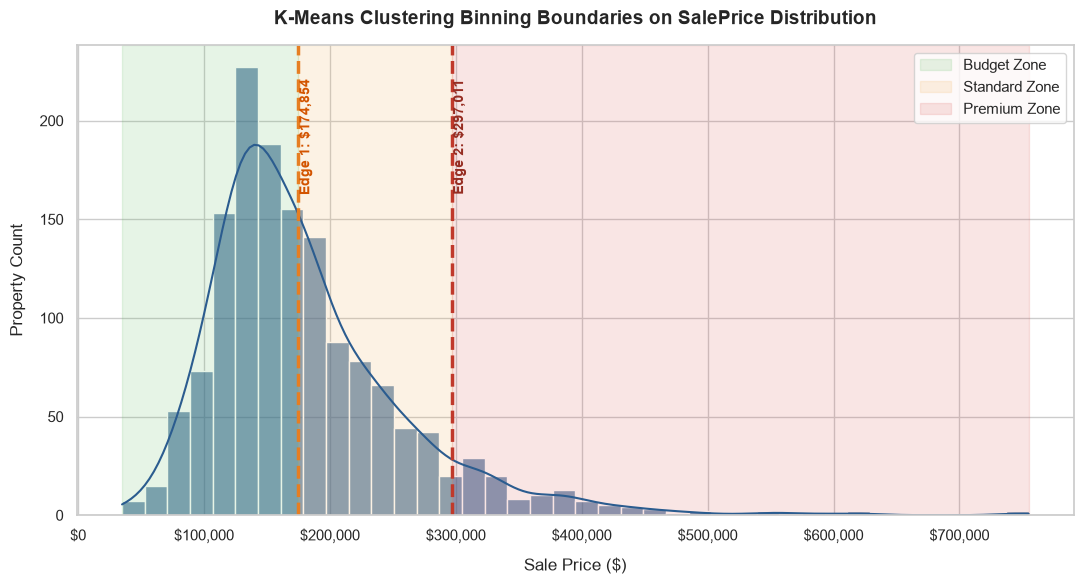

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import KBinsDiscretizer
kbd = KBinsDiscretizer(n_bins=3, encode='ordinal', strategy='kmeans')
kbd.fit(df_encoded_standard[['SalePrice']])

# Extract the exact bin edges calculated by the K-Means discretizer
# kbd.bin_edges_[0] contains the [Min, Edge1, Edge2, Max] boundaries
bin_edges = kbd.bin_edges_[0]

print("--- Calculated K-Means Bin Edges ---")
print(f"Min (Lower Bound):        ${round(bin_edges[0]):,}")
print(f"Budget/Standard Edge:     ${round(bin_edges[1]):,}")
print(f"Standard/Premium Edge:    ${round(bin_edges[2]):,}")
print(f"Max (Upper Bound):        ${round(bin_edges[3]):,}")

# Set a clean visual style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(11, 6))

# Plot baseline histogram and smooth distribution line
sns.histplot(
    data=df_encoded_standard, 
    x='SalePrice', 
    kde=True, 
    bins=40, 
    color='#2b5c8f', 
    edgecolor='white',
    alpha=0.6
)

# Color palettes for shading the regions
colors = ['#5cb85c', '#f0ad4e', '#d9534f']  # Green, Orange, Red
labels = ['Budget', 'Standard', 'Premium']

# Shade the background regions dynamically based on K-Means boundaries
for i in range(3):
    plt.axvspan(bin_edges[i], bin_edges[i+1], color=colors[i], alpha=0.15, label=f'{labels[i]} Zone')
    
# Draw sharp vertical boundary lines between the clusters
plt.axvline(bin_edges[1], color='#e67e22', linestyle='--', linewidth=2.5)
plt.axvline(bin_edges[2], color='#c0392b', linestyle='--', linewidth=2.5)

# Annotate the specific edge values explicitly onto the plot canvas
plt.text(bin_edges[1], plt.gca().get_ylim()[1]*0.8, f' Edge 1: ${round(bin_edges[1]):,}', 
         color='#d35400', weight='bold', fontsize=10, rotation=90, va='center')
plt.text(bin_edges[2], plt.gca().get_ylim()[1]*0.8, f' Edge 2: ${round(bin_edges[2]):,}', 
         color='#962d22', weight='bold', fontsize=10, rotation=90, va='center')

# Format axes and labels with currency format
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"${x:,.0f}"))
plt.title('K-Means Clustering Binning Boundaries on SalePrice Distribution', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Sale Price ($)', fontsize=12, labelpad=10)
plt.ylabel('Property Count', fontsize=12, labelpad=10)

plt.legend(loc='upper right', fontsize=11)
plt.tight_layout()
plt.show()

4. Decision Tree Binning

--- Calculated Decision Tree Bin Edges ---
Min (Lower Bound):        $34,900
Budget/Standard Edge:     $220,500
Standard/Premium Edge:    $352,000
Max (Upper Bound):        $755,000


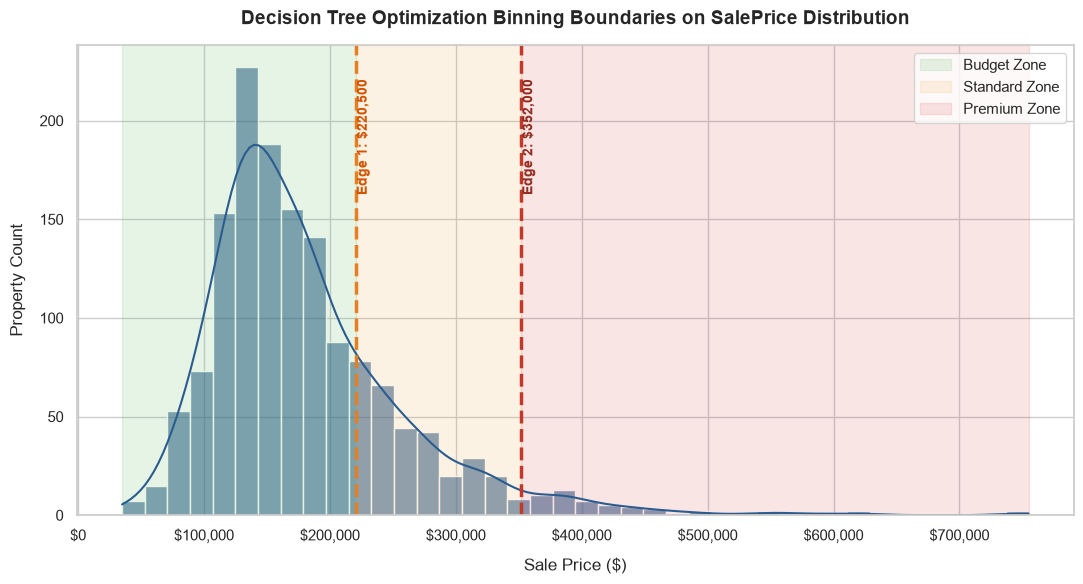

In [ ]:
from sklearn.tree import DecisionTreeRegressor
dt_binner = DecisionTreeRegressor(max_leaf_nodes=3, random_state=42)
X_feature = df_encoded_standard[['SalePrice']]
y_target = df_encoded_standard['SalePrice']


dt_binner.fit(X_feature, y_target)

# Extract the minimum, maximum, and internal tree split thresholds
min_price = df_encoded_standard['SalePrice'].min()
max_price = df_encoded_standard['SalePrice'].max()

# tree_thresholds contains the sorted internal cut boundaries chosen by the tree node splits
tree_thresholds = sorted(dt_binner.tree_.threshold[dt_binner.tree_.threshold != -2])

# Construct full array of edges: [Min, First Split, Second Split, Max]
bin_edges = [min_price, tree_thresholds[0], tree_thresholds[1], max_price]

print("--- Calculated Decision Tree Bin Edges ---")
print(f"Min (Lower Bound):        ${round(bin_edges[0]):,}")
print(f"Budget/Standard Edge:     ${round(bin_edges[1]):,}")
print(f"Standard/Premium Edge:    ${round(bin_edges[2]):,}")
print(f"Max (Upper Bound):        ${round(bin_edges[3]):,}")

# Set a clean visual style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(11, 6))

# Plot baseline histogram and smooth distribution line
sns.histplot(
    data=df_encoded_standard, 
    x='SalePrice', 
    kde=True, 
    bins=40, 
    color='#2b5c8f', 
    edgecolor='white',
    alpha=0.6
)

# Color palettes for shading the regions
colors = ['#5cb85c', '#f0ad4e', '#d9534f']  # Green, Orange, Red
labels = ['Budget', 'Standard', 'Premium']

# Shade the background regions dynamically based on Decision Tree optimal MSE boundaries
for i in range(3):
    plt.axvspan(bin_edges[i], bin_edges[i+1], color=colors[i], alpha=0.15, label=f'{labels[i]} Zone')
    
# Draw sharp vertical boundary lines exactly where the tree made its decisions
plt.axvline(bin_edges[1], color='#e67e22', linestyle='--', linewidth=2.5)
plt.axvline(bin_edges[2], color='#c0392b', linestyle='--', linewidth=2.5)

# Annotate the specific edge values explicitly onto the plot canvas
plt.text(bin_edges[1], plt.gca().get_ylim()[1]*0.8, f' Edge 1: ${round(bin_edges[1]):,}', 
         color='#d35400', weight='bold', fontsize=10, rotation=90, va='center')
plt.text(bin_edges[2], plt.gca().get_ylim()[1]*0.8, f' Edge 2: ${round(bin_edges[2]):,}', 
         color='#962d22', weight='bold', fontsize=10, rotation=90, va='center')

# Format axes and labels with currency format
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"${x:,.0f}"))
plt.title('Decision Tree Optimization Binning Boundaries on SalePrice Distribution', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Sale Price ($)', fontsize=12, labelpad=10)
plt.ylabel('Property Count', fontsize=12, labelpad=10)

plt.legend(loc='upper right', fontsize=11)
plt.tight_layout()
plt.show()

5. Statistical Deviation (Standard Score / Z-score) Binning

--- Calculated Statistical Deviation Bin Edges ---
Mean Price (μ):          $180,921
Std Dev (σ):             $79,443
Min (Lower Bound):        $34,900
Budget/Standard Edge:     $101,479
Standard/Premium Edge:    $260,364
Max (Upper Bound):        $755,000


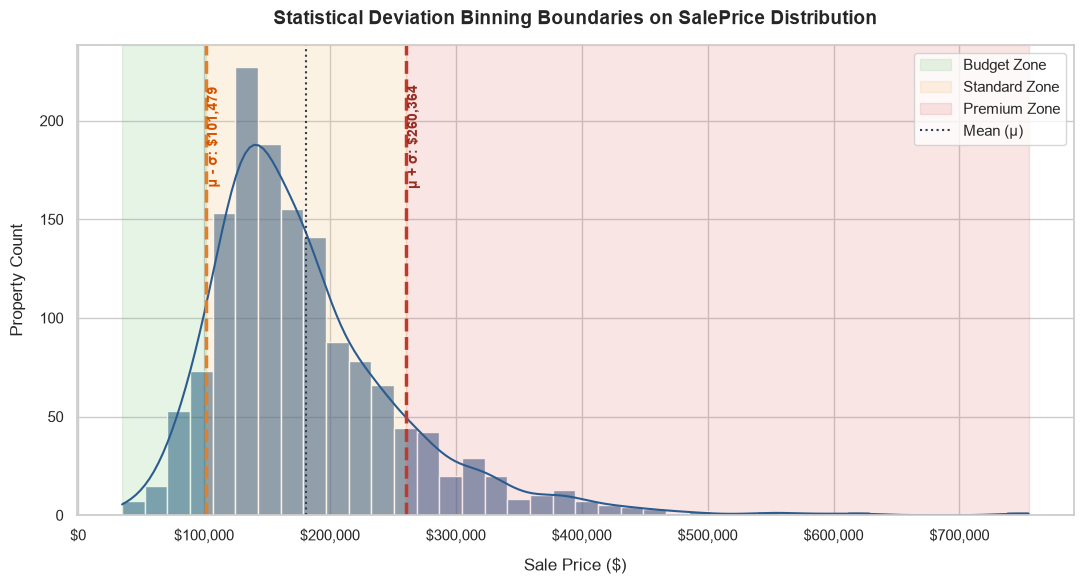

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Extract the minimum, maximum, and statistical thresholds
min_price = df_encoded_standard['SalePrice'].min()
max_price = df_encoded_standard['SalePrice'].max()

mean_price = df_encoded_standard['SalePrice'].mean()
std_price = df_encoded_standard['SalePrice'].std()

lower_threshold = mean_price - std_price
upper_threshold = mean_price + std_price

# Construct the full array of edges for visualization: [Min, Mean-Std, Mean+Std, Max]
# Note: If lower_threshold is less than min_price, the lower edge automatically clips to Min.
bin_edges = [min_price, max(min_price, lower_threshold), upper_threshold, max_price]

print("--- Calculated Statistical Deviation Bin Edges ---")
print(f"Mean Price (\u03bc):          ${round(mean_price):,}")
print(f"Std Dev (\u03c3):             ${round(std_price):,}")
print(f"Min (Lower Bound):        ${round(bin_edges[0]):,}")
print(f"Budget/Standard Edge:     ${round(bin_edges[1]):,}")
print(f"Standard/Premium Edge:    ${round(bin_edges[2]):,}")
print(f"Max (Upper Bound):        ${round(bin_edges[3]):,}")

# Set a clean visual style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(11, 6))

# Plot baseline histogram and smooth distribution line
sns.histplot(
    data=df_encoded_standard, 
    x='SalePrice', 
    kde=True, 
    bins=40, 
    color='#2b5c8f', 
    edgecolor='white',
    alpha=0.6
)

# Color palettes for shading the regions
colors = ['#5cb85c', '#f0ad4e', '#d9534f']  # Green, Orange, Red
labels = ['Budget', 'Standard', 'Premium']

# Shade the background regions dynamically based on Z-Score standard deviation thresholds
for i in range(3):
    plt.axvspan(bin_edges[i], bin_edges[i+1], color=colors[i], alpha=0.15, label=f'{labels[i]} Zone')
    
# Draw sharp vertical boundary lines exactly at \u03bc - \u03c3 and \u03bc + \u03c3
if lower_threshold > min_price:
    plt.axvline(lower_threshold, color='#e67e22', linestyle='--', linewidth=2.5)
plt.axvline(upper_threshold, color='#c0392b', linestyle='--', linewidth=2.5)

# Add a thin line tracking the exact mean (\u03bc) for visual symmetry
plt.axvline(mean_price, color='#2c3e50', linestyle=':', linewidth=1.5, label='Mean (\u03bc)')

# Annotate the specific edge values explicitly onto the plot canvas
if lower_threshold > min_price:
    plt.text(lower_threshold, plt.gca().get_ylim()[1]*0.8, f' \u03bc - \u03c3: ${round(lower_threshold):,}', 
             color='#d35400', weight='bold', fontsize=10, rotation=90, va='center')
plt.text(upper_threshold, plt.gca().get_ylim()[1]*0.8, f' \u03bc + \u03c3: ${round(upper_threshold):,}', 
         color='#962d22', weight='bold', fontsize=10, rotation=90, va='center')

# Format axes and labels with currency format
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"${x:,.0f}"))
plt.title('Statistical Deviation Binning Boundaries on SalePrice Distribution', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Sale Price ($)', fontsize=12, labelpad=10)
plt.ylabel('Property Count', fontsize=12, labelpad=10)

plt.legend(loc='upper right', fontsize=11)
plt.tight_layout()
plt.show()

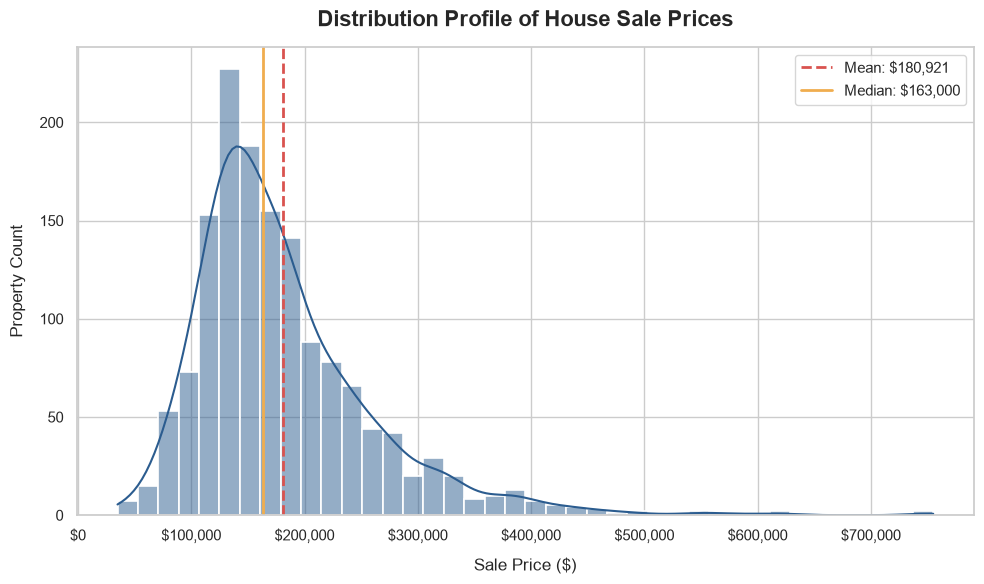

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean visual style
sns.set_theme(style="whitegrid")

# Create the figure container
plt.figure(figsize=(10, 6))

# Plot the histogram with a Kernel Density Estimate (KDE) line
sns.histplot(
    data=df_encoded_standard, 
    x='SalePrice', 
    kde=True, 
    bins=40, 
    color='#2b5c8f', # Professional slate-blue color
    edgecolor='white',
    linewidth=1.2
)

# Calculate key statistics for reference lines
mean_price = df_encoded_standard['SalePrice'].mean()
median_price = df_encoded_standard['SalePrice'].median()

# Add vertical indicator lines for Mean and Median
plt.axvline(mean_price, color='#d9534f', linestyle='--', linewidth=2, label=f'Mean: ${mean_price:,.0f}')
plt.axvline(median_price, color='#f0ad4e', linestyle='-', linewidth=2, label=f'Median: ${median_price:,.0f}')

# Format axis labels and values with thousands separators
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"${x:,.0f}"))

# Set text properties
plt.title('Distribution Profile of House Sale Prices', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Sale Price ($)', fontsize=12, labelpad=10)
plt.ylabel('Property Count', fontsize=12, labelpad=10)

# Optimize legend and layout
plt.legend(fontsize=11, loc='upper right')
plt.tight_layout()

# Display the plot
plt.show()

1. Inserting the new column 'Price_Category' into the df_encoded_standard and df_encoded_minmax using K means clustering approach

In [ ]:
# 1. Predict the bin indices (0, 1, or 2) for both dataframes
# Note: K-Means only cares about the raw 'SalePrice' values, which are identical 
# in both dfs before scaling, so we transform using the same fitted kbd object.
bins_standard = kbd.transform(df_encoded_standard[['SalePrice']]).flatten()
bins_minmax = kbd.transform(df_encoded_minmax[['SalePrice']]).flatten()

# 2. Define a mapping dictionary from numeric bins to text labels
category_map = {0: 'Budget', 1: 'Standard', 2: 'Premium'}

# 3. Map the labels and assign the new column to both dataframes
df_encoded_standard['Price_Category'] = pd.Series(bins_standard).map(category_map).values
df_encoded_minmax['Price_Category'] = pd.Series(bins_minmax).map(category_map).values

# --- Verification Check ---
print("--- df_encoded_standard Value Counts ---")
print(df_encoded_standard['Price_Category'].value_counts())

print("\n--- Sample Rows (Standard) ---")
print(df_encoded_standard[['SalePrice', 'Price_Category']].head())

--- df_encoded_standard Value Counts ---
Price_Category
Budget      826
Standard    518
Premium     116
Name: count, dtype: int64

--- Sample Rows (Standard) ---
   SalePrice Price_Category
0     208500       Standard
1     181500       Standard
2     223500       Standard
3     140000         Budget
4     250000       Standard


In [ ]:
df_encoded_standard.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Columns: 226 entries, MSSubClass to Price_Category
dtypes: float64(25), int64(200), str(1)
memory usage: 2.5 MB


In [ ]:
df_encoded_standard.to_csv('df_encoded_standard.csv', index=False)

In [ ]:
df_encoded_minmax.to_csv('df_encoded_minmax.csv', index=False)
